# **Atividade Prática**
<font size=3>

- **Tema:** tarefa de classificação.
- **Prazo de entrega:** 01 de Junho.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSfhkf8HoNNsr9WixEVVlxh8-pFK-rnXsLKN_OLRH_Tg5-5SmA/viewform?usp=sharing&ouid=111377632325147218671).

---

## **Enunciado:**
<font size=3>

Vamos realizar uma tarefa de **análise de sentimentos** com o conjundo de dados [IMDB movie reviews](https://keras.io/api/datasets/imdb/), também disponível no diretório $\text{dataset/}\,$. Realize os seguintes passos para resolver a **tarefa de classificação**:

### **1º Passo:**
<font size=3>

- Importe o *dataset*, embaralhe as amostras, e defina os dados textuais e alvo;
- **Plote** um histograma com os tamanhos das sentenças, a fim de definir um bom tamanho para a entrada do modelo.


### **Imports, variáveis globais e leitura do dataset**

In [18]:
# Não precisamos montar o drive pois os arquivos estão disponíveis localmente
#from google.colab import drive
#drive.mount('/content/drive/')

In [41]:
from collections import Counter
from keras import layers, Model
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib.ticker import FuncFormatter
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

RANDOM_STATE = 42

Lemos o dataset local, embaralhamos utilizando RANDOM_STATE como semente para garantir reprodutibilidade do experimento, e por fim mostramos o shape e uma pequena amostra dos datos.

In [20]:
df = pd.read_csv('./dataset/imdb.csv', ).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(df.shape)
df.head()

(50000, 2)


,reviews,label
0,River's Edge is more than just the story of a ...,1
1,Evening is the beautiful story of the flawed l...,1
2,I question anyone saying they don't care for t...,1
3,This docu-drama is what you would expect from ...,1
4,"As several posters have ""hinted,"" this is a so...",0


### Definindo uma função de pré-processamento para o texto

Definimos a função de pré-processamento no inicio para aplicá-la antes de analisar o tamanho das entradas. Assim operamos sobre um conjunto de dados limpo desde as definições preliminares.

In [21]:
def Preprocessor(x):

    # tudo em minúsculo
    x = tf.strings.lower(x)

    # remove tags html
    x = tf.strings.regex_replace(x, r"<[^>]+>", " ")

    # remove caracteres especiais
    x = tf.strings.regex_replace(x, r"[^\w\s]", "")

    # remove espaços em excesso
    x = tf.strings.regex_replace(x, r" {2,}", " ")

    # remove espaços extras no início e no final
    x = tf.strings.strip(x)

    return x

print (Preprocessor("   Hello,   the  world's  !   ").numpy().decode("utf-8"))

hello the worlds


Agora utilizamos a função de processamento para limpar o dataset.

In [22]:
df_clean = df.copy()

df_clean["reviews"] = df_clean["reviews"].apply(
    lambda x: Preprocessor(x).numpy().decode("utf-8")
)

df_clean.head()

,reviews,label
0,rivers edge is more than just the story of a m...,1
1,evening is the beautiful story of the flawed l...,1
2,i question anyone saying they dont care for th...,1
3,this docudrama is what you would expect from r...,1
4,as several posters have hinted this is a sorry...,0


Mas definimos `X_text` e `y` em função do dataset original `df`, pois vamos adicionar a função de pré-processamento no pipeline.

In [23]:
X_text = df["reviews"]
y = df["label"]

### Analisando a limpeza dos textos (função de `Preprocessor`)

Primeiro uma revisão básica do dataset

In [24]:
print(f"Quantidade de amostras: {len(df_clean)}")

print("\nValores ausentes:")
print(df_clean[["reviews", "label"]].isna().sum())

print("\nReviews vazias após a limpeza:")
print((df_clean["reviews"].str.len() == 0).sum())

print("\nDistribuição das classes:")
print(y.value_counts())

Quantidade de amostras: 50000

Valores ausentes:
reviews    0
label      0
dtype: int64

Reviews vazias após a limpeza:
0

Distribuição das classes:
label
1    25000
0    25000
Name: count, dtype: int64


Podemos observar 50.000 amostras perfeitamente balanceadas nas classes 0 e 1. Não existem valores vazios ou nulos no dataset.

Vamos observar então os tokens/palavras mais comuns no texto para analisar se existe necessidade de adicionar alguma funcionalidade na função de pré-processamento.
Analisando os dados decidimos adicionar a eliminação de tags HTML na função de pré-processamento. Abaixo mostramos apenas o resultado final.

In [25]:
from collections import Counter

tokens = " ".join(df_clean["reviews"]).split()
token_counts = Counter(tokens)

token_counts.most_common(200)

[('the', 663910),
 ('and', 320683),
 ('a', 320571),
 ('of', 288481),
 ('to', 266928),
 ('is', 210499),
 ('in', 185063),
 ('it', 154901),
 ('i', 152108),
 ('this', 149898),
 ('that', 136535),
 ('was', 95403),
 ('as', 91242),
 ('with', 87003),
 ('for', 86834),
 ('movie', 85220),
 ('but', 81777),
 ('film', 76026),
 ('on', 66999),
 ('not', 60051),
 ('you', 59816),
 ('are', 58258),
 ('his', 57305),
 ('have', 55111),
 ('be', 52917),
 ('he', 51962),
 ('one', 51475),
 ('its', 49118),
 ('at', 46541),
 ('all', 45705),
 ('by', 44174),
 ('an', 42830),
 ('they', 41548),
 ('from', 40373),
 ('who', 40188),
 ('so', 39637),
 ('like', 39061),
 ('or', 34950),
 ('just', 34872),
 ('her', 34489),
 ('about', 34055),
 ('if', 33590),
 ('out', 33050),
 ('has', 32927),
 ('some', 31004),
 ('there', 30839),
 ('what', 30317),
 ('good', 28912),
 ('when', 27892),
 ('more', 27869),
 ('very', 27598),
 ('my', 24762),
 ('even', 24581),
 ('no', 24459),
 ('up', 24457),
 ('would', 24036),
 ('time', 23958),
 ('she', 23894),


### Definindo `MAX_LENGTH`

Agora que chegamos numa limpeza aparentemente razoável, vamos ver o tamanho das sentenças. Primeiro definimos uma coluna `length` no dataset `df_clean` para analisar sua distribuição numérica.

In [26]:
df_clean["length"] = df_clean["reviews"].str.split().str.len()

Criamos funções auxiliares para descrever a variável numérica.

In [27]:
def br_number(value, decimals=0):
    '''
    Formata um número para o formato brasileiro com a quantidade de casas decimais desejada.
    '''
    formatted = f"{value:,.{decimals}f}"
    return formatted.replace(",", "X").replace(".", ",").replace("X", ".")

In [28]:
def descrever_variavel_numerica(y, nome="variável", decimals=0):
    '''
    Descreve uma variável numérica com percentis e assimetria.
    '''
    percentis = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]

    print(f"=== Percentis de {nome} ===")

    for p in percentis:
        valor = y.quantile(p)
        qtd_acumulada = (y <= valor).sum()

        print(
            f"P {int(p * 100):>3}%:"
            f" {br_number(valor, decimals):>15}"
            f" | qtd acumulada: {qtd_acumulada:>5}"
        )

    print()

    print(f"=== Assimetria de {nome} ===")
    print(f"{'Média':<10}: {br_number(y.mean(), decimals):>15}")
    print(f"{'Mediana':<10}: {br_number(y.median(), decimals):>15}")
    print(f"{'Mínimo':<10}: {br_number(y.min(), decimals):>15}")
    print(f"{'Máximo':<10}: {br_number(y.max(), decimals):>15}")
    print(f"{'Skewness':<10}: {br_number(y.skew(), 2):>15}")
    print()

E utilizamos as funções definidas para descrever o tamanho das sentenças:

In [29]:
descrever_variavel_numerica(
    df_clean["length"],
    nome="tamanho das reviews",
    decimals=0
)

=== Percentis de tamanho das reviews ===
P   0%:               4 | qtd acumulada:     1
P   1%:              41 | qtd acumulada:   537
P   5%:              62 | qtd acumulada:  2528
P  10%:              88 | qtd acumulada:  5033
P  25%:             125 | qtd acumulada: 12746
P  50%:             171 | qtd acumulada: 25117
P  75%:             276 | qtd acumulada: 37507
P  90%:             445 | qtd acumulada: 45019
P  95%:             581 | qtd acumulada: 47503
P  99%:             892 | qtd acumulada: 49500
P 100%:           2.459 | qtd acumulada: 50000

=== Assimetria de tamanho das reviews ===
Média     :             228
Mediana   :             171
Mínimo    :               4
Máximo    :           2.459
Skewness  :            2,17



A distribuição do tamanho das reviews apresenta assimetria à direita. A mediana é de 171 palavras, enquanto a média é de 228 palavras, diferença pode ser explicada pela presença de reviews mais longas na distribuição. O coeficiente de assimetria (skewness) de 2,17 confirma esse comportamento. Em relação aos percentis, 75% das reviews possuem até 276 palavras, 90% possuem até 445 palavras e 95% possuem até 581 palavras. Embora a maior review contenha 2.459 palavras, os valores extremos representam uma parcela pequena do conjunto: apenas 1% das reviews ultrapassa 892 palavras. Esses resultados indicam que a definição do tamanho máximo da entrada deve priorizar os percentis intermediários, evitando dimensionar o modelo com base nos casos extremos e reduzindo a quantidade desnecessária de preenchimento (padding) nas sequências menores.


Para confirmar isso vamos produzir um gráfico de distribuição da quantidade de palavras no dataset. Primeiro definimos funções auxiliares para criar o gráfico.

In [30]:
def formatar_milhoes_br(x, pos):
    '''
    Formata um número para o formato brasileiro com a quantidade de casas decimais desejada.
    '''
    return f"{x / 1_000_000:.1f}".replace(".", ",")


def plotar_histograma_com_percentis(
    y,
    nome="variável",
    limite_percentil=0.99,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=True
):
    '''
    Plota um histograma dos dados, juntamente com os percentis que desejamos marcar no grafico.
    '''
    limite = y.quantile(limite_percentil)
    y_filtrado = y[y <= limite]

    plt.figure(figsize=(12, 6))
    plt.hist(y_filtrado, bins=bins, edgecolor="black", alpha=0.7)

    if usar_milhoes:
        plt.gca().xaxis.set_major_formatter(FuncFormatter(formatar_milhoes_br))
        xlabel = f"{nome} em milhões"
    else:
        xlabel = nome

    altura_max = plt.ylim()[1]

    for p in percentis_marcados:
        valor = y.quantile(p)

        if valor <= limite:
            plt.axvline(valor, linestyle="--", linewidth=1.5, alpha=0.8)
            plt.text(
                valor,
                altura_max * 0.95,
                f"P{int(p * 100)}",
                rotation=90,
                ha="center",
                va="top"
            )

    plt.title(f"Distribuição de {nome} até o percentil {int(limite_percentil * 100)}")
    plt.xlabel(xlabel)
    plt.ylabel("Frequência")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

Depois utilizamos a função para gerar o gráfico com a distribuição da quantidade de palavras por review do dataset.

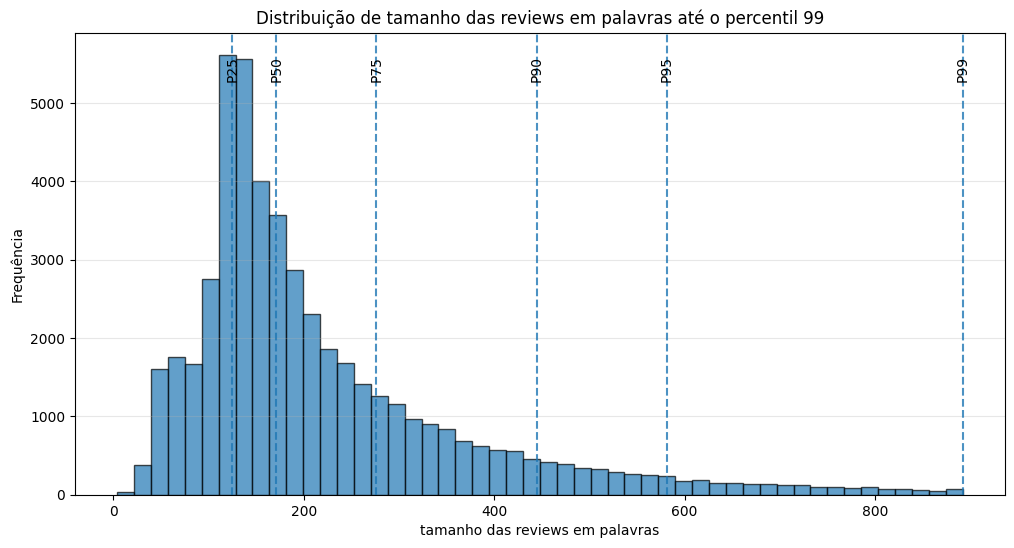

In [32]:
plotar_histograma_com_percentis(
    df_clean["length"],
    nome="tamanho das reviews em palavras",
    limite_percentil=0.99,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=False
)

O histograma evidencia uma distribuição assimétrica à direita, com maior concentração de reviews entre aproximadamente 100 e 300 palavras e uma redução progressiva da frequência à medida que o tamanho aumenta. A presença de uma cauda longa indica que existem reviews significativamente maiores que a maioria, embora representem uma parcela reduzida do conjunto de dados.

Os percentis destacados no gráfico permitem observar esse comportamento de forma mais precisa. Enquanto 50% das reviews possuem até 171 palavras e 75% possuem até 276 palavras, o percentil 95 corresponde a 581 palavras. Isso significa que 95% das reviews possuem tamanho igual ou inferior a esse valor.

Dessa forma, foi escolhido o percentil 95 como referência para definir o tamanho máximo das entradas do modelo. Essa escolha permite preservar a maior parte do conteúdo textual disponível, ao mesmo tempo em que evita dimensionar todas as entradas com base em casos extremos. Reviews maiores que esse limite serão truncadas, enquanto reviews menores receberão preenchimento até o tamanho definido. Esse critério representa um equilíbrio entre retenção de informação e custo computacional.


In [39]:
MAX_LENGTH = int(df_clean["length"].quantile(0.95))

print(MAX_LENGTH)

581


### Definindo `VOCAB_SIZE`

Agora vamos avaliar a cobertura dos tokens em função do tamanho do vocabulário. O que queremos responder/definir é o seguinte: qual o tamanho do vocabulário nos permite extrair o máximo desempenho do dataset sem comprometer demais os recursos computacionais necessários para processamento?

Para isso vamos tentar mostrar, em termos de cobertura de vocabulário, qual o ganho marginal se obtém ao se aumentar o tamanho do vocabulário. Buscaremos identificar um ponto onde aumentar o tamanho do vocabulário gera um incremento marginal na cobertura.

Para isso, primeiro vamos contar a quantidade de tokens total e quantidade de tokens únicos do dataset.

In [42]:
# Conta todas as ocorrências de palavras no dataset pré-processado
token_counts = Counter(
    token
    for review in df_clean["reviews"]
    for token in review.split()
)

# Ordena os tokens do mais frequente para o menos frequente
frequencias_ordenadas = sorted(token_counts.values(), reverse=True)

total_ocorrencias = sum(frequencias_ordenadas)
total_tokens_unicos = len(frequencias_ordenadas)

print(f"Total de ocorrências de palavras: {br_number(total_ocorrencias)}")
print(f"Quantidade de palavras distintas: {br_number(total_tokens_unicos)}")

Total de ocorrências de palavras: 11.395.898
Quantidade de palavras distintas: 167.168


E definir alguns valores-alvo de vocab_size para averiguar a cobertura.

In [54]:
vocab_sizes = [
     1000,
     2000,
     5000,
    10000,
    15000,
    20000,
    30000,
    50000
]

Agora, para verificar a cobertura, vamos criar um dataset contendo, para cada um dos `vocab_size` propostos, a quantidade e percentual de ocorrências cobertas, e a quantidade e percentual de ocorrências fora do vocabulário (OOV: Out Of Vocabulary).

In [55]:
resultados_vocabulario = []

for vocab_size in vocab_sizes:
    tamanho_efetivo = min(vocab_size, total_tokens_unicos)

    ocorrencias_cobertas = sum(frequencias_ordenadas[:tamanho_efetivo])
    ocorrencias_oov = total_ocorrencias - ocorrencias_cobertas

    resultados_vocabulario.append({
        "VOCAB_SIZE": vocab_size,
        "palavras incluídas": tamanho_efetivo,
        "ocorrências cobertas": ocorrencias_cobertas,
        "cobertura (%)": ocorrencias_cobertas / total_ocorrencias * 100,
        "ocorrências OOV": ocorrencias_oov,
        "OOV (%)": ocorrencias_oov / total_ocorrencias * 100
    })

df_vocabulario = pd.DataFrame(resultados_vocabulario)

df_vocabulario.style.format({
    "VOCAB_SIZE": "{:,.0f}",
    "palavras incluídas": "{:,.0f}",
    "ocorrências cobertas": "{:,.0f}",
    "cobertura (%)": "{:.2f}",
    "ocorrências OOV": "{:,.0f}",
    "OOV (%)": "{:.2f}"
})

,VOCAB_SIZE,palavras incluídas,ocorrências cobertas,cobertura (%),ocorrências OOV,OOV (%)
0,"1,000","1,000","8,649,734",75.90,"2,746,164",24.10
1,"2,000","2,000","9,375,607",82.27,"2,020,291",17.73
2,"5,000","5,000","10,187,270",89.39,"1,208,628",10.61
3,"10,000","10,000","10,660,796",93.55,"735,102",6.45
4,"15,000","15,000","10,875,801",95.44,"520,097",4.56
5,"20,000","20,000","11,000,147",96.53,"395,751",3.47
6,"30,000","30,000","11,134,286",97.70,"261,612",2.30
7,"50,000","50,000","11,245,722",98.68,"150,176",1.32


Os resultados mostram que a cobertura cresce rapidamente até aproximadamente 10.000 palavras e passa a apresentar ganhos marginais progressivamente menores a partir desse ponto. Com 10.000 palavras, o vocabulário cobre 93,55% das ocorrências do corpus, deixando 6,45% como tokens fora do vocabulário. Ao aumentar para 15.000, a cobertura sobe para 95,44%, um ganho de 1,89 ponto percentual. Com 20.000, a cobertura chega a 96,53%, representando ganho adicional de apenas 1,09 ponto percentual. A partir daí, o crescimento se torna ainda menos expressivo: usar 50.000 palavras eleva a cobertura para 98,68%, mas exige uma matriz de embeddings cinco vezes maior que a configuração com 10.000.

Vamos visualizar essa curva num gráfico para definir o tamanho do vocabulario que será utilizado.

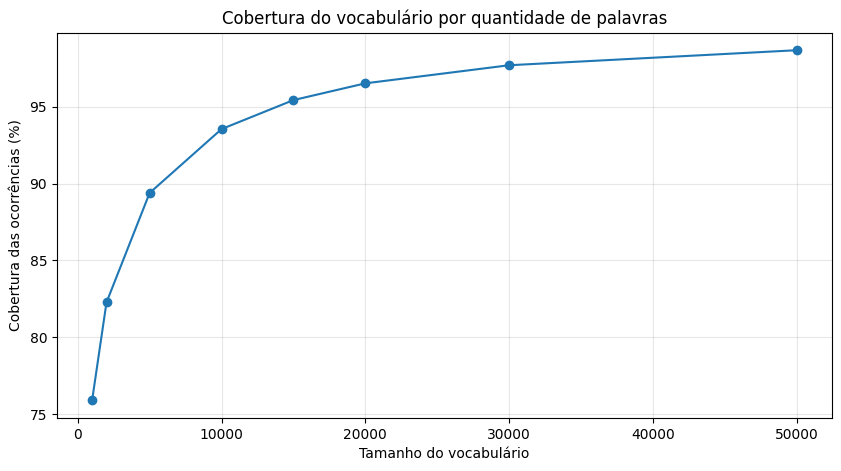

In [56]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_vocabulario["VOCAB_SIZE"],
    df_vocabulario["cobertura (%)"],
    marker="o"
)

plt.title("Cobertura do vocabulário por quantidade de palavras")
plt.xlabel("Tamanho do vocabulário")
plt.ylabel("Cobertura das ocorrências (%)")
plt.grid(True, alpha=0.3)

plt.show()

O gráfico indica um ponto de inflexão entre 10.000 e 15.000 palavras. Considerando o equilíbrio entre cobertura do vocabulário, custo computacional e quantidade de parâmetros, 15.000 nos parece uma escolha mais adequada para nosso caso. Esse valor cobre pouco mais de 95% das ocorrências e reduz a proporção de tokens desconhecidos para 4,56%, sem aumentar excessivamente a complexidade do modelo.

In [57]:
VOCAB_SIZE = 15000

### **2º Passo:**
<font size=3>

- Realize a transformação da variável alvo;
- Defina o objeto da vetorização dos dados textuais com a função [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/):
    - Faça operações *regex* customizadas, caso seja necessário.
    - Defina o tamanho do vocabulário (`vocab_size`), o tamanho da entrada/janela do modelo (`max_len`), e a dimensão do vetor *embedding* (`embed_dim`);
    - Iremos realizar a vetorização (indexação) dentro da rede neural, ou seja, o objeto da vetorização irá processar os dados após a camada `layers.Input()`.
    <br>

- Divida os dados em treninamento (90%) e teste (10%). Os dados de validação serão divididos na função `model.fit()`.  

A definição das operações de limpeza dos dados (`Preprocessor`), do tamanho de entrada do modelo (`MAX_LENGTH=581`) e do tamanho do vocabulário (`VOCAB_SIZE=1500`) foram realizadas e justificadas no passo anterior.

Ja o número de dimensões do embedding não pode ser definido exclusivamente em função do vocabulário. Ele deve ser tratado como um hiperparâmetro do modelo e deve ser definido em função do desempenho do modelo. Poucas dimensões podem não ser suficientes para representar adequadamente a relação entre as palavras; muitas dimensões podem gerar overfitting; portanto, vamos iniciar com um valor mais ou menos arbitrário, moderado, que nos permita testar o modelo: `EMBED_DIM = 100`

In [58]:
EMBED_DIM = 100 

text_vectorizer = layers.TextVectorization(
    name="TextVectorizer",
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_LENGTH,
    standardize=Preprocessor
)

### **3º Passo:**
<font size=3>

- Desenvolva a primeira versão da **arquitetura neural**:
    - Já sabemos o tamanho da entrada, o tamanho da saída e sua função de ativação:
 
        <font size=2>
        
        ```python
        x_in = layers.Input(shape=(1, ), dtype=tf.string)
            
        ```
        <font size=3>
        
    - A camada [`Embedding`](https://keras.io/api/layers/core_layers/embedding/) irá retornar um *array* de formato (`max_len`, `embed_dim`), assim, precisamos torná-lo unidimensional para poder ser acoplado à próxima camada. Para isso, utilize:
        - Uma camada de [`Flatten`](https://keras.io/api/layers/reshaping_layers/flatten/);
        - Ou uma camada de [`GlobalAveragePooling1D`](https://keras.io/api/layers/pooling_layers/global_average_pooling1d/).
        <br>

- Compile o modelo com um otimizador ([`SGR`](https://keras.io/api/optimizers/sgd/), [`RMSprop`](https://keras.io/api/optimizers/rmsprop/), [`Adam`](https://keras.io/api/optimizers/adam/));
- Defina a função de perda e métrica de acordo com a natureza do problema.
  

### **4º Passo:**
<font size=3>

- Treine o modelo com o método `.fit()`, definindo as variáveis:
    - `validation_split`: porcentagem de dados para validação;
    - `epochs`: número de épocas para o treinamento;
    - `batch_size`: tamanho do lote da amostragem dos dados de entrada.
      

### **5º Passo:**
<font size=3>

- Quando definida uma boa arquitetura naural, faça o **treinamento final** do modelo com todos os dados de treinamento (sem validação).

### **6º Passo:**
<font size=3>

- Realize a avaliação do modelo com o método `.evaluate()`;
- **Imprima na tela** 10 predições com seus respectivos valores verdadeiros.

### **8º Passo:**
<font size=3>

- Faça o **relatório da modelagem da arquitetura neural** em uma **célula _markdown_**. Descreva alterações que você teve de realizar na arquitetura a fim de aprimorar a performance do predição.
      